In [ ]:
# ── Parameters (injected by papermill) ─────────────────
# Defaults for manual runs. The orchestrator overrides CSV_PATH via papermill -p.
CSV_PATH     = ""   # leave empty to auto-detect latest combined_zones CSV
PLOTS_DIR    = "outputs/latest"
EXCLUDE_COLS = ""   # comma-separated columns to drop before EDA

# Data and libraries

In [4]:
# standard packaging
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for headless/papermill runs

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={"figure.figsize":(10,8)})

from IPython.display import HTML

In [ ]:
import os, glob

os.makedirs(PLOTS_DIR, exist_ok=True)

_search_dir = "csv"

if not CSV_PATH:
    _csvs = sorted(glob.glob(os.path.join(_search_dir, "combined_zones_*.csv")))
    if _csvs:
        CSV_PATH = _csvs[-1]
        print(f"Auto-detected latest CSV: {CSV_PATH}")
    else:
        raise FileNotFoundError("No combined_zones CSV found in " + _search_dir)
elif not os.path.exists(CSV_PATH):
    _csvs = sorted(glob.glob(os.path.join(os.path.dirname(CSV_PATH), "combined_zones_*.csv")))
    if _csvs:
        CSV_PATH = _csvs[-1]
        print(f"Specified CSV not found — using latest: {CSV_PATH}")
    else:
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

NYC_spots = pd.read_csv(CSV_PATH, dtype={"tract_id": str})
print(f"Loaded {len(NYC_spots)} rows x {NYC_spots.shape[1]} cols from {CSV_PATH}")

# ── Merge 5 zone types → 2 classes (binary) ────────
# Commercial stays as-is (clearly separable by amenity/shop density)
# Mixed-Use + Residential → Residential (indistinguishable in OSM features)
# Institutional + Open Space → Other → DROPPED (too noisy, few samples)
_CLASS_MAP = {
    "Commercial": "Commercial",
    "Mixed-Use": "Residential",
    "Residential": "Residential",
    "Institutional": "Other",
    "Open Space": "Other",
}
NYC_spots["zone_type"] = NYC_spots["zone_type"].map(_CLASS_MAP)
NYC_spots = NYC_spots[NYC_spots["zone_type"] != "Other"].reset_index(drop=True)
print(f"Dropped Other class — {len(NYC_spots)} tracts remaining")
print(f"\nClass mapping (5 → 3):")
for orig, new in _CLASS_MAP.items():
    print(f"  {orig} → {new}")

# Rename for compatibility with downstream cells
NYC_spots = NYC_spots.rename(columns={"zone_type": "label"})
if "borough" in NYC_spots.columns:
    NYC_spots = NYC_spots.rename(columns={"borough": "location"})

print(f"\nFinal class distribution:")
print(NYC_spots["label"].value_counts())

In [ ]:
print(NYC_spots["label"].value_counts())

In [14]:
#inspect data
NYC_spots.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location         8775 non-null   object 
 1   osm_id           8775 non-null   int64  
 2   name             8528 non-null   object 
 3   lat              8775 non-null   float64
 4   lon              8775 non-null   float64
 5   label            8775 non-null   object 
 6   distance_m       8775 non-null   float64
 7   lot_area_sqft    8768 non-null   float64
 8   highway_type     8775 non-null   object 
 9   lanes            6814 non-null   float64
 10  dist_bus_stop_m  8775 non-null   float64
 11  dist_hospital_m  8775 non-null   float64
 12  dist_school_m    8775 non-null   float64
 13  dist_park_m      8775 non-null   float64
 14  res_ratio        8379 non-null   float64
 15  com_ratio        8379 non-null   float64
 16  median_income    0 non-null      float64
dtypes: float64(12)

In [17]:
print(f"Total rows: {len(NYC_spots)}")
print("\nNull counts per column:")
print(NYC_spots.isnull().sum())

Total rows: 8775

Null counts per column:
location              0
osm_id                0
name                247
lat                   0
lon                   0
label                 0
distance_m            0
lot_area_sqft         7
highway_type          0
lanes              1961
dist_bus_stop_m       0
dist_hospital_m       0
dist_school_m         0
dist_park_m           0
res_ratio           396
com_ratio           396
median_income      8775
dtype: int64


## Drop rows with any null values

In [24]:
_exclude = [c.strip() for c in EXCLUDE_COLS.split(",") if c.strip() in NYC_spots.columns]
NYC_clean = NYC_spots.drop(columns=_exclude) if _exclude else NYC_spots.copy()

# Drop columns that are 100% null
_all_null = [c for c in NYC_clean.columns if NYC_clean[c].isna().all()]
if _all_null:
    NYC_clean = NYC_clean.drop(columns=_all_null)
    print(f"Dropped 100% null columns: {_all_null}")

# Impute partially null numeric columns with median
_num_cols = NYC_clean.select_dtypes(include="number").columns
for c in _num_cols:
    n_null = NYC_clean[c].isna().sum()
    if n_null > 0:
        _med = NYC_clean[c].median()
        NYC_clean[c] = NYC_clean[c].fillna(_med)
        print(f"Imputed {c}: {n_null} nulls → median {_med:.2f}")

# Drop remaining rows with nulls in non-numeric columns
NYC_clean = NYC_clean.dropna()

print(f"\nDropped columns: {_exclude}")
print(f"Rows remaining: {len(NYC_clean)}")
print(f"\nNull counts after cleaning:")
print(NYC_clean.isnull().sum())

Rows remaining: 8153

Null counts after cleaning:
location           0
osm_id             0
name               0
lat                0
lon                0
label              0
distance_m         0
lot_area_sqft      0
highway_type       0
dist_bus_stop_m    0
dist_hospital_m    0
dist_school_m      0
dist_park_m        0
res_ratio          0
com_ratio          0
dtype: int64


In [25]:
NYC_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8153 entries, 1 to 8774
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location         8153 non-null   object 
 1   osm_id           8153 non-null   int64  
 2   name             8153 non-null   object 
 3   lat              8153 non-null   float64
 4   lon              8153 non-null   float64
 5   label            8153 non-null   object 
 6   distance_m       8153 non-null   float64
 7   lot_area_sqft    8153 non-null   float64
 8   highway_type     8153 non-null   object 
 9   dist_bus_stop_m  8153 non-null   float64
 10  dist_hospital_m  8153 non-null   float64
 11  dist_school_m    8153 non-null   float64
 12  dist_park_m      8153 non-null   float64
 13  res_ratio        8153 non-null   float64
 14  com_ratio        8153 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 1019.1+ KB


In [ ]:
if "location" in NYC_clean.columns:
    print(NYC_clean.groupby(["location", "label"]).size().unstack(fill_value=0))
else:
    print(NYC_clean["label"].value_counts())

In [27]:
print(NYC_clean["label"].value_counts())

label
food_drink               3796
retail                   2128
personal_care             742
leisure_entertainment     498
health                    392
finance                   256
office_professional       176
hospitality               165
Name: count, dtype: int64


In [ ]:
print(NYC_clean["label"].unique())

Exploratory Data Analysis (EDA)



In [ ]:
print(NYC_clean["label"].value_counts())

label
food_drink               1184
retail                    596
leisure_entertainment     154
personal_care             111
finance                   106
hospitality               103
office_professional        90
health                     78
Name: count, dtype: int64


because of the huge gap i'm taking a sample of 78 data point from each label to check if a pattern exist

In [ ]:
if "location" in NYC_clean.columns:
    spots = sorted(NYC_clean["location"].unique().tolist())
    print("Locations found:", spots)
    for spot in spots:
        spot_df = NYC_clean[NYC_clean["location"] == spot]
        min_class = spot_df["label"].value_counts().min()
        sample = pd.concat([
            grp.sample(min(len(grp), min_class), random_state=11)
            for _, grp in spot_df.groupby("label")
        ]).reset_index(drop=True)
        print("\n=== " + spot + " ===")
        sample.info()
        print(sample["label"].value_counts())
else:
    spots = []
    print("No location column — skipping per-location sampling")

In [ ]:
if "location" in NYC_clean.columns and len(NYC_clean["location"].unique()) > 1:
    sns.countplot(x="location", hue="label", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    sns.countplot(x="label", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
plt.title("Zone Type Distribution")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_countplot_zone_type.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
if "amenity_density" in NYC_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="label", y="amenity_density", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
    plt.title("Amenity Density by Zone Type")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/02_boxplot_amenity_density.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
if "dist_subway_mean" in NYC_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="label", y="dist_subway_mean", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
    plt.title("Mean Subway Distance by Zone Type")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/03_boxplot_dist_subway.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
if "shop_density_km2" in NYC_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="label", y="shop_density_km2", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
    plt.title("Shop Density by Zone Type")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/04_boxplot_shop_density.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
if "landuse_entropy" in NYC_clean.columns and "amenity_density" in NYC_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="landuse_entropy", y="amenity_density", hue="label", data=NYC_clean)
    plt.title("Land Use Entropy vs Amenity Density")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/05_scatter_entropy_density.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
_eda_cols = ["amenity_density", "shop_density_km2", "dist_subway_mean", "dist_bus_mean",
             "intersection_density", "tourism_density", "landuse_entropy",
             "avg_floors", "pedestrian_rank_mean"]
numeric_cols = [c for c in _eda_cols if c in NYC_clean.columns]

if numeric_cols:
    _min_c = NYC_clean["label"].value_counts().min()
    _s = pd.concat([
        grp.sample(min(len(grp), _min_c), random_state=11)
        for _, grp in NYC_clean.groupby("label")
    ]).reset_index(drop=True)
    sns.pairplot(_s[numeric_cols + ["label"]], hue="label")
    plt.suptitle("Zone Finding — Feature Pairplot", y=1.02)
    plt.savefig(f"{PLOTS_DIR}/06_pairplot.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# Feature distributions by zone type — top discriminating features
_box_cols = ["amenity_density", "shop_density_km2", "tourism_density",
             "intersection_density", "landuse_entropy", "avg_floors"]
_box_cols = [c for c in _box_cols if c in NYC_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), _box_cols):
    sns.boxplot(x="label", y=col, data=NYC_clean, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(col)
plt.suptitle("Key Feature Distributions by Zone Type", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07_feature_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
_eda_cols = ["amenity_count_total", "amenity_density", "avg_floors", "avg_yearbuilt",
             "lot_area_mean", "total_bldg_area", "building_count",
             "landuse_entropy", "landuse_hhi",
             "dist_subway_mean", "dist_bus_mean", "transit_stop_count",
             "intersection_density", "hotel_count", "tourism_poi_count",
             "tourism_density", "pedestrian_rank_mean", "pct_high_traffic_segments",
             "shop_count", "shop_density_km2", "shop_type_entropy", "brand_ratio"]
numeric_cols = [c for c in _eda_cols if c in NYC_clean.columns]
NYC_num = NYC_clean[numeric_cols]
plt.figure(figsize=(16, 13))
sns.heatmap(NYC_num.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Feature selection: keep only features with proven signal ──

# Drop ID/geo columns
_always_drop = ["tract_id", "location", "tract_lat", "tract_lon", "tract_lot_count"]

# Drop features with NO discriminating power (confirmed via plots)
_no_signal = [
    "dist_subway_mean",        # identical distribution across all zones
    "dist_bus_mean",           # identical distribution across all zones
    "pedestrian_rank_mean",    # same discrete distribution for all classes
    "pedestrian_rank_max",     # same issue
    "intersection_density",    # dominated by outliers, no class separation
    "transit_stop_count",      # no discrimination
    "pct_high_traffic_segments",  # same distribution across classes
]

# Drop redundant features (correlation > 0.7 with a kept feature)
_redundant = [
    "amenity_count_total",     # = amenity_density (r=1.00)
    "amenity_count_food_drink",  # captured by amenity_ratio_food_drink
    "amenity_count_retail",    # captured by shop_density
    "amenity_count_services",  # weak signal
    "amenity_count_office",    # weak signal
    "amenity_count_hotel",     # = tourism_density
    "amenity_count_entertainment",  # weak signal
    "amenity_count_education", # weak signal
    "amenity_count_healthcare",  # weak signal
    "amenity_ratio_retail",    # captured by shop_density
    "amenity_ratio_services",  # weak signal
    "amenity_ratio_office",    # weak signal
    "amenity_ratio_hotel",     # = tourism_density
    "amenity_ratio_entertainment",  # weak signal
    "amenity_ratio_education", # weak signal
    "amenity_ratio_healthcare",  # weak signal
    "shop_count",              # = shop_density_km2 (r=0.91)
    "hotel_count",             # = tourism_density (r=0.96)
    "tourism_poi_count",       # = tourism_density (r=1.00)
    "tourism_ratio",           # derived from amenity_count which is dropped
    "lot_area_mean",           # low correlation with everything
    "landuse_hhi",             # = landuse_entropy inverted (r=-0.92)
]

_to_drop = [c for c in _always_drop + _no_signal + _redundant if c in NYC_clean.columns]
NYC_model = NYC_clean.drop(columns=_to_drop)

print(f"Dropped {len(_to_drop)} columns")
print(f"\nKept {len(NYC_model.columns)} features:")
print(NYC_model.columns.tolist())
print(f"\nShape: {NYC_model.shape}")

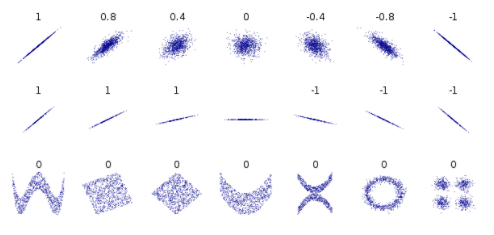

Adelie has smaller culmen length than the other two species
Gentoo has larger flipper length than the other two species
Gentoo are also heavier than the other two species
Adelie are the only penguins living on the three islands, chinstrap only on Dream and Gentoo only on Biscoe

Flipper length and body mass  positevly correlated length features > bigger animal, need for stronger flippers and larger beak to eat more

# Data Inspection

#Data prep

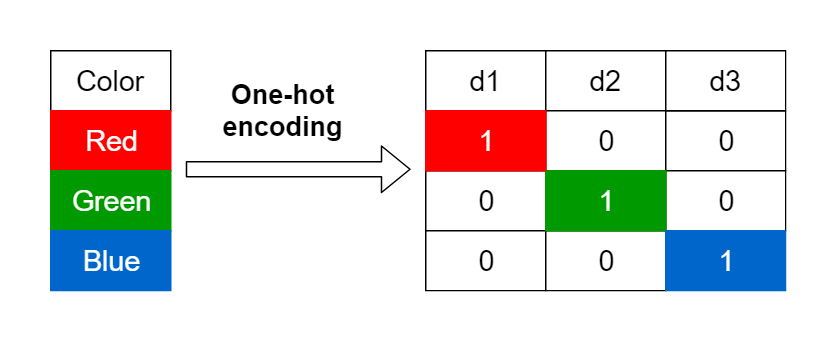

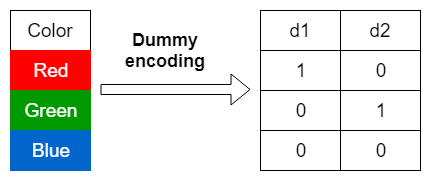

encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

NYC_model["label"] = encoder.fit_transform(NYC_model["label"])
print("Classes:", list(encoder.classes_))
NYC_model

In [68]:
import numpy as np

numeric_cols = [c for c in NYC_model.columns if c != "label"]

for col in numeric_cols:
    print(f"{col}: min={NYC_model[col].min():.1f}, max={NYC_model[col].max():.1f}, mean={NYC_model[col].mean():.1f}, median={NYC_model[col].median():.1f}")

lot_area_sqft: min=216.0, max=4227757.0, mean=16323.0, median=3750.0
highway_type: min=0.0, max=11.0, mean=4.9, median=5.0
dist_bus_stop_m: min=0.0, max=359.8, mean=70.7, median=62.3
dist_hospital_m: min=0.0, max=949.9, mean=217.5, median=199.7
dist_school_m: min=4.4, max=582.8, mean=192.5, median=173.5
dist_park_m: min=0.5, max=758.2, mean=165.0, median=132.9
res_ratio: min=0.0, max=1.0, mean=0.5, median=0.7


scaling

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [70]:
X = NYC_model.drop(columns=["label"])
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.16446556,  0.04710781, -0.63089658, ...,  1.48694615,
        -0.97095535, -1.24125519],
       [-0.15148445,  0.83092403,  0.61503496, ...,  1.25866769,
        -1.05202406, -1.24125519],
       [-0.14073012,  0.83092403,  0.1162267 , ...,  1.36260724,
        -0.94419481, -1.24125519],
       ...,
       [-0.18268466,  0.04710781,  1.77383842, ..., -0.18385796,
        -1.03156011, -0.59461001],
       [-0.17394202,  0.83092403,  0.61939136, ..., -0.72201231,
        -0.37120431,  1.10368487],
       [-0.03583113,  0.04710781,  0.50830306, ...,  0.70691377,
        -1.18740094, -1.24125519]])

In [71]:
import numpy as np
y = np.asarray(NYC_model["label"])
y

array([7, 7, 7, ..., 1, 6, 3])

splitting

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

#Train model

In [73]:
# Import K-fold crossvalidation
from sklearn.model_selection import cross_val_score

# Import Classification Report for later evaluatoion of performance
from sklearn.metrics import classification_report

Logistic Regression

In [74]:
# Import and instantiate the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, class_weight="balanced")

# K-fold cross-validation (splitting the 80% into 5 chunks, using 4 to train and 1 to evaluate)
scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)



[0.13256705 0.15019157 0.14417178 0.14187117 0.14263804]


In [75]:
# Model training
model.fit(X_train, y_train)

# Model performance on the test-set
print(model.score(X_test, y_test))

0.15511955855303494


# skip

In [ ]:
target_names_penguins = encoder.inverse_transform(list(set(y_test)))
y_pred = model.predict(X_test)


In [ ]:
print(target_names_penguins)


['Adelie' 'Chinstrap' 'Gentoo']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have 

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

class_names = list(encoder.classes_)
confmatrix = confusion_matrix(y_test, y_pred)
fig, ax = plot_confusion_matrix(conf_mat=confmatrix, colorbar=True,
                      show_absolute=True, show_normed=True, hide_spines=True,
                      class_names=class_names)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/09_confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

# XG boost

In [ ]:
import xgboost as xgb

model = xgb.XGBClassifier(random_state=14, eval_metric="mlogloss")

scores = cross_val_score(model, X_train, y_train, cv=5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_test, y_test))

In [77]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.29      0.11      0.16        54
           1       0.52      0.78      0.62       765
           2       0.65      0.24      0.35        82
           3       0.00      0.00      0.00        31
           4       0.21      0.07      0.10        88
           5       0.24      0.11      0.15        35
           6       0.30      0.10      0.15       142
           7       0.43      0.33      0.37       434

    accuracy                           0.48      1631
   macro avg       0.33      0.22      0.24      1631
weighted avg       0.44      0.48      0.44      1631



In [78]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset


In [ ]:
confmatrix = confusion_matrix(y_test, y_pred)
fig, ax = plot_confusion_matrix(conf_mat=confmatrix, colorbar=True,
                      show_absolute=True, show_normed=True,
                      class_names=class_names)
plt.title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/10_confusion_matrix_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## Random forest

In [80]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight="balanced", random_state=42)

scores = cross_val_score(model_rf, X_train, y_train, cv=5)
print(f"Cross-val scores: {scores}")
print(f"Mean: {scores.mean():.3f}")

model_rf.fit(X_train, y_train)
print(f"\nTest accuracy: {model_rf.score(X_test, y_test):.3f}")

Cross-val scores: [0.4697318  0.45823755 0.49846626 0.47546012 0.49079755]
Mean: 0.479

Test accuracy: 0.484


In [ ]:
from sklearn.metrics import classification_report

y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

confmatrix = confusion_matrix(y_test, y_pred_rf)
fig, ax = plot_confusion_matrix(conf_mat=confmatrix, colorbar=True,
                      show_absolute=True, show_normed=True,
                      class_names=class_names)
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/11_confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()